# Notebook 10 — Prophet: Erhardt Station (Structural Break Test)
**Does Prophet handle a -17.1% structural decline better than SARIMAX?**

Notebooks 08–09 found that Prophet + weather outperforms SARIMAX by ~25% on Hirsch and Olympia. This notebook applies the same framework to **Erhardt** — a station with a confirmed structural decline in the test period (2024–2025) — to test whether Prophet's flexible trend detection is an advantage or liability when a regime shift occurs outside the training window.

| Part | Content |
|------|---------|
| 1 | Data loading (Erhardt: 82-day test gap) |
| 2 | Seasonality mode selection + baseline Prophet |
| 3 | Prophet + weather regressors |
| 4 | Performance comparison vs SARIMAX |
| 5 | Systematic bias analysis |
| 6 | Forecast visualisation |
| 7 | Interpretation and key finding |
| 8 | Artefact export and summary |

**SARIMAX benchmarks (notebook 07):**  
Fourier-only: 1,542 RMSE | Fourier+weather: 844 RMSE (45.3% gain) | Mean residual: −34 (over-predicts 51.6% of days)

**Test period note:** Erhardt has an 82-day sensor gap (Sep 6 – Nov 26, 2024). These rows are absent from the CSV, so `test_df` naturally contains only the 769 observed days — no imputation needed.

In [1]:
import sys, warnings, logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import holidays
from prophet import Prophet

logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
warnings.filterwarnings('ignore')

sys.path.insert(0, '../src')

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11, 'axes.labelsize': 12,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'legend.frameon': False,
})
sns.set_theme(style='whitegrid')

FIGURES = Path('../results/figures')
TABLES  = Path('../results/tables')
for p in [FIGURES, TABLES]:
    p.mkdir(parents=True, exist_ok=True)

WEATHER_COLS = ['max_temp', 'sunshine_hours', 'precipitation']

TRAIN_START = '2013-01-01'
TRAIN_END   = '2022-12-31'
VAL_START   = '2023-01-01'
VAL_END     = '2023-12-31'
TEST_START  = '2024-01-01'
TEST_END    = '2026-04-30'

GAP_START = pd.Timestamp('2024-09-06')
GAP_END   = pd.Timestamp('2024-11-26')

# ── Load SARIMAX benchmarks from nb07 outputs (no hardcoding) ────────────
_erhardt_perf = pd.read_csv(TABLES / 'erhardt_performance.csv')
_fou_row  = _erhardt_perf[_erhardt_perf['Configuration'] == 'SARIMAX + Fourier K=4'].iloc[0]
_full_row = _erhardt_perf[_erhardt_perf['Configuration'] == 'SARIMAX + Fourier + weather'].iloc[0]
SARIMAX_FOURIER_RMSE = float(_fou_row['Test 7d RMSE'])
SARIMAX_FULL_RMSE    = float(_full_row['Test 7d RMSE'])
SARIMAX_FULL_MAE     = float(_full_row['Test 7d MAE'])
SARIMAX_WEATHER_GAIN = round((SARIMAX_FOURIER_RMSE - SARIMAX_FULL_RMSE) / SARIMAX_FOURIER_RMSE * 100, 1)

_erhardt_bias       = pd.read_csv(TABLES / 'erhardt_bias_analysis.csv')
SARIMAX_MEAN_RESIDUAL = float(_erhardt_bias.iloc[0]['Mean residual'])
SARIMAX_PCT_OVER      = float(_erhardt_bias.iloc[0]['Pct over-predicted'])

# Load cross-station Prophet gains for in-text comparison
_gain_df     = pd.read_csv(TABLES / 'prophet_weather_gain_comparison.csv')
_h_prop      = _gain_df[_gain_df['Station'].str.startswith('Hirsch')  & (_gain_df['Model'] == 'Prophet')].iloc[0]
_o_prop      = _gain_df[_gain_df['Station'].str.startswith('Olympia') & (_gain_df['Model'] == 'Prophet')].iloc[0]
HIRSCH_PROPHET_GAIN  = float(_h_prop['Weather gain (%)'])
OLYMPIA_PROPHET_GAIN = float(_o_prop['Weather gain (%)'])

# ── notebook prefix: all figures saved as nb10_<name>.png ────────────────

# Bavaria public holidays for Prophet (2013-2026)
_by_hols = holidays.Germany(state='BY', years=range(2013, 2027))
holiday_df = pd.DataFrame([
    {'ds': pd.Timestamp(d), 'holiday': name, 'lower_window': 0, 'upper_window': 0}
    for d, name in _by_hols.items()
])
NB = 'nb10'

def savefig(name):
    full_name = f'{NB}_{name}'
    plt.savefig(FIGURES / f'{full_name}.png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f'  saved → results/figures/{full_name}.png')

print('Setup complete.')
print(f'Erhardt SARIMAX: Fourier RMSE={SARIMAX_FOURIER_RMSE}, Full RMSE={SARIMAX_FULL_RMSE}, gain={SARIMAX_WEATHER_GAIN}%')
print(f'Mean residual={SARIMAX_MEAN_RESIDUAL}, Pct over-predicted={SARIMAX_PCT_OVER}%')

/Users/sousadaniela/time-series-rad/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Setup complete.
Erhardt SARIMAX: Fourier RMSE=1541.9, Full RMSE=843.5, gain=45.3%
Mean residual=-33.9, Pct over-predicted=51.6%


## Part 1 — Data Loading

Erhardt has no training gaps. The 82-day test gap (Sep–Nov 2024) is handled automatically: those rows are absent from the CSV, so `test_df` contains exactly 769 observed days (851 calendar − 82 gap).

Train: 3,652 days  (2013-01-01 – 2022-12-31)
Val:   365 days  (2023-01-01 – 2023-12-31)
Test:  769 days  (769 observed / 851 calendar — 82-day gap 2024-09-06–2024-11-26)

Erhardt target range: 102 – 12283 cyclists/day


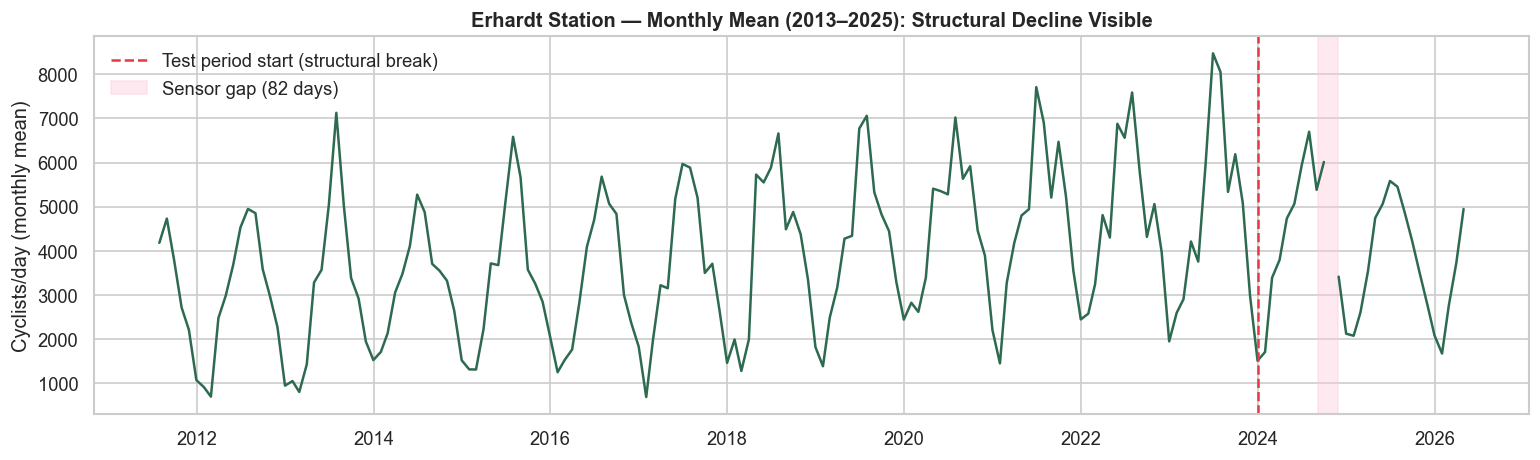

  saved → results/figures/nb10_fig_01_erhardt_overview.png


In [2]:
df_raw = pd.read_csv('../data/processed/master_bike_data.csv', parse_dates=['date'])

erhardt = (
    df_raw[df_raw['station'] == 'Erhardt']
    .set_index('date')
    .sort_index()[['total'] + WEATHER_COLS]
    .dropna()
)

df_prophet = erhardt.reset_index().rename(columns={'date': 'ds', 'total': 'y'})
df_prophet['precipitation'] = np.log1p(df_prophet['precipitation'])

train_df    = df_prophet[(df_prophet['ds'] >= TRAIN_START) & (df_prophet['ds'] <= TRAIN_END)].copy()
val_df      = df_prophet[(df_prophet['ds'] >= VAL_START) & (df_prophet['ds'] <= VAL_END)].copy()
test_df     = df_prophet[(df_prophet['ds'] >= TEST_START) & (df_prophet['ds'] <= TEST_END)].copy()
trainval_df = pd.concat([train_df, val_df], ignore_index=True)

print(f'Train: {len(train_df):,} days  ({train_df.ds.min().date()} – {train_df.ds.max().date()})')
print(f'Val:   {len(val_df):,} days  ({val_df.ds.min().date()} – {val_df.ds.max().date()})')
print(f'Test:  {len(test_df):,} days  (769 observed / 851 calendar — 82-day gap {GAP_START.date()}–{GAP_END.date()})')
print(f'\nErhardt target range: {erhardt["total"].min():.0f} – {erhardt["total"].max():.0f} cyclists/day')

# Structural break context plot
fig, ax = plt.subplots(figsize=(13, 4))
monthly = erhardt['total'].resample('ME').mean()
ax.plot(monthly.index, monthly.values, color='#2d6a4f', lw=1.5)
ax.axvline(pd.Timestamp(TEST_START), color='#e63946', ls='--', lw=1.5,
           label='Test period start (structural break)')
ax.axvspan(GAP_START, GAP_END, color='#ffc8dd', alpha=0.4, label='Sensor gap (82 days)')
ax.set_title('Erhardt Station — Monthly Mean (2013–2025): Structural Decline Visible')
ax.set_ylabel('Cyclists/day (monthly mean)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
savefig('fig_01_erhardt_overview')

In [3]:
def rolling_rmse_mae(y_true, y_pred, horizon=7):
    """Non-overlapping rolling window evaluation — matches all other notebooks."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    rmses, maes = [], []
    for start in range(0, n - horizon + 1, horizon):
        sl = slice(start, start + horizon)
        err = y_true[sl] - y_pred[sl]
        rmses.append(np.sqrt(np.mean(err**2)))
        maes.append(np.mean(np.abs(err)))
    return float(np.mean(rmses)), float(np.mean(maes))


def fit_predict(train, future_df, mode='multiplicative', use_weather=False,
                changepoint_prior_scale=0.05):
    m = Prophet(
        seasonality_mode=mode,
        holidays=holiday_df,
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=changepoint_prior_scale,
    )
    if use_weather:
        for col in WEATHER_COLS:
            m.add_regressor(col)
    m.fit(train)
    forecast = m.predict(future_df)
    return m, forecast['yhat'].values


val_future  = val_df[['ds'] + WEATHER_COLS].copy()
test_future = test_df[['ds'] + WEATHER_COLS].copy()
print('Helpers defined.')

Helpers defined.


## Part 2 — Seasonality Mode Selection + Baseline Prophet

Both Hirsch and Olympia selected **multiplicative** seasonality. Testing whether Erhardt agrees.

In [4]:
print('Testing seasonality modes on validation...')
mode_results = {}
for mode in ['additive', 'multiplicative']:
    _, preds = fit_predict(train_df, val_future[['ds']], mode=mode)
    rmse, mae = rolling_rmse_mae(val_df['y'].values, preds)
    mode_results[mode] = {'Val 7d RMSE': round(rmse, 1), 'Val 7d MAE': round(mae, 1)}
    print(f'  {mode:>15s}: Val RMSE={rmse:.1f}, MAE={mae:.1f}')

best_mode = min(mode_results, key=lambda m: mode_results[m]['Val 7d RMSE'])
print(f'\nSelected: {best_mode} (Hirsch and Olympia both selected: multiplicative)')

# Baseline — val
_, base_val_preds = fit_predict(train_df, val_future[['ds']], mode=best_mode)
base_val_rmse, base_val_mae = rolling_rmse_mae(val_df['y'].values, base_val_preds)

# Baseline — test (refit on train+val)
print('\nFitting baseline Prophet for test...')
_, base_test_preds = fit_predict(trainval_df, test_future[['ds']], mode=best_mode)
base_test_rmse, base_test_mae = rolling_rmse_mae(test_df['y'].values, base_test_preds)
base_mean_resid = float(np.mean(test_df['y'].values - base_test_preds))

print(f'\nProphet baseline ({best_mode})')
print(f'  Val  7d RMSE: {base_val_rmse:.1f}  MAE: {base_val_mae:.1f}')
print(f'  Test 7d RMSE: {base_test_rmse:.1f}  MAE: {base_test_mae:.1f}')
print(f'  Mean residual (test): {base_mean_resid:.1f}')
print(f'  SARIMAX Fourier-only: {SARIMAX_FOURIER_RMSE} — gap: {base_test_rmse - SARIMAX_FOURIER_RMSE:+.1f}')

Testing seasonality modes on validation...


16:16:26 - cmdstanpy - INFO - Chain [1] start processing


16:16:26 - cmdstanpy - INFO - Chain [1] done processing


         additive: Val RMSE=1549.2, MAE=1371.9


16:16:26 - cmdstanpy - INFO - Chain [1] start processing


...

16:16:27 - cmdstanpy - INFO - Chain [1] done processing



Fitting baseline Prophet for test...


16:16:28 - cmdstanpy - INFO - Chain [1] start processing


16:16:28 - cmdstanpy - INFO - Chain [1] done processing



Prophet baseline (multiplicative)
  Val  7d RMSE: 1491.2  MAE: 1314.1
  Test 7d RMSE: 1576.1  MAE: 1345.8
  Mean residual (test): -802.4
  SARIMAX Fourier-only: 1541.9 — gap: +34.2


## Part 3 — Prophet + Weather Regressors

Adding `max_temp`, `sunshine_hours`, and `log1p(precipitation)`. On Hirsch and Olympia, weather reduced RMSE by ~30%. On Erhardt, weather was confirmed **not** to have caused the structural decline (2024–25 was warmer and sunnier than average), so the question is whether weather regressors still improve fit despite the regime shift.

In [5]:
print(f'Fitting Prophet + weather ({best_mode}) — val...')
_, wx_val_preds = fit_predict(train_df, val_future, mode=best_mode, use_weather=True)
wx_val_rmse, wx_val_mae = rolling_rmse_mae(val_df['y'].values, wx_val_preds)

print(f'Fitting Prophet + weather ({best_mode}) — test...')
_, wx_test_preds = fit_predict(trainval_df, test_future, mode=best_mode, use_weather=True)
wx_test_rmse, wx_test_mae = rolling_rmse_mae(test_df['y'].values, wx_test_preds)
wx_mean_resid = float(np.mean(test_df['y'].values - wx_test_preds))

weather_gain = (base_test_rmse - wx_test_rmse) / base_test_rmse * 100

print(f'\nProphet + weather ({best_mode})')
print(f'  Val  7d RMSE: {wx_val_rmse:.1f}  MAE: {wx_val_mae:.1f}')
print(f'  Test 7d RMSE: {wx_test_rmse:.1f}  MAE: {wx_test_mae:.1f}')
print(f'  Mean residual (test): {wx_mean_resid:.1f}')
print(f'  Weather gain: {weather_gain:.1f}%  (Hirsch: {HIRSCH_PROPHET_GAIN:.1f}%, Olympia: {OLYMPIA_PROPHET_GAIN:.1f}%)')
print(f'\n  vs SARIMAX+weather: {wx_test_rmse - SARIMAX_FULL_RMSE:+.1f} RMSE ({(wx_test_rmse - SARIMAX_FULL_RMSE)/SARIMAX_FULL_RMSE*100:+.1f}%)')

Fitting Prophet + weather (multiplicative) — val...


16:16:28 - cmdstanpy - INFO - Chain [1] start processing


16:16:29 - cmdstanpy - INFO - Chain [1] done processing


Fitting Prophet + weather (multiplicative) — test...


16:16:29 - cmdstanpy - INFO - Chain [1] start processing


16:16:30 - cmdstanpy - INFO - Chain [1] done processing



Prophet + weather (multiplicative)
  Val  7d RMSE: 916.8  MAE: 753.5
  Test 7d RMSE: 870.5  MAE: 745.8
  Mean residual (test): -329.1
  Weather gain: 44.8%  (Hirsch: 33.1%, Olympia: 31.6%)

  vs SARIMAX+weather: +27.0 RMSE (+3.2%)


## Part 4 — Performance Comparison vs SARIMAX

In [6]:
results = [
    {
        'Model': 'Prophet baseline (no weather)',
        'Val 7d RMSE': round(base_val_rmse, 1),
        'Test 7d RMSE': round(base_test_rmse, 1),
        'Val 7d MAE': round(base_val_mae, 1),
        'Test 7d MAE': round(base_test_mae, 1),
        'Mean residual': round(base_mean_resid, 1),
    },
    {
        'Model': f'Prophet + weather ({best_mode})',
        'Val 7d RMSE': round(wx_val_rmse, 1),
        'Test 7d RMSE': round(wx_test_rmse, 1),
        'Val 7d MAE': round(wx_val_mae, 1),
        'Test 7d MAE': round(wx_test_mae, 1),
        'Mean residual': round(wx_mean_resid, 1),
    },
    {
        'Model': 'SARIMAX + Fourier K=4 (benchmark)',
        'Val 7d RMSE': None, 'Test 7d RMSE': SARIMAX_FOURIER_RMSE,
        'Val 7d MAE': None,  'Test 7d MAE': None, 'Mean residual': None,
    },
    {
        'Model': 'SARIMAX + Fourier + weather (benchmark)',
        'Val 7d RMSE': None, 'Test 7d RMSE': SARIMAX_FULL_RMSE,
        'Val 7d MAE': None,  'Test 7d MAE': SARIMAX_FULL_MAE,
        'Mean residual': SARIMAX_MEAN_RESIDUAL,
    },
]
perf_df = pd.DataFrame(results)
print(perf_df.to_string(index=False))

gap_pct = (wx_test_rmse - SARIMAX_FULL_RMSE) / SARIMAX_FULL_RMSE * 100
print(f'\nProphet+weather vs SARIMAX+weather: {gap_pct:+.1f}% — SARIMAX wins')

                                  Model  Val 7d RMSE  Test 7d RMSE  Val 7d MAE  Test 7d MAE  Mean residual
          Prophet baseline (no weather)       1491.2        1576.1      1314.1       1345.8         -802.4
     Prophet + weather (multiplicative)        916.8         870.5       753.5        745.8         -329.1
      SARIMAX + Fourier K=4 (benchmark)          NaN        1541.9         NaN          NaN            NaN
SARIMAX + Fourier + weather (benchmark)          NaN         843.5         NaN        703.6          -33.9

Prophet+weather vs SARIMAX+weather: +3.2% — SARIMAX wins


## Part 5 — Systematic Bias Analysis

SARIMAX's most important advantage on Erhardt is not just lower RMSE — it has dramatically less systematic over-prediction.

In [7]:
test_actual = test_df['y'].values
test_dates  = test_df['ds'].values

resid_base = test_actual - base_test_preds
resid_wx   = test_actual - wx_test_preds

bias_df = pd.DataFrame([
    {'Model': 'SARIMAX + weather',       'Mean residual': SARIMAX_MEAN_RESIDUAL, '% over-predicted': SARIMAX_PCT_OVER},
    {'Model': 'Prophet baseline',         'Mean residual': round(base_mean_resid, 1), '% over-predicted': round((resid_base < 0).mean()*100, 1)},
    {'Model': 'Prophet + weather (auto)', 'Mean residual': round(wx_mean_resid, 1),   '% over-predicted': round((resid_wx < 0).mean()*100, 1)},
])
print('Systematic bias comparison (negative = over-prediction):')
print(bias_df.to_string(index=False))

Systematic bias comparison (negative = over-prediction):
                   Model  Mean residual  % over-predicted
       SARIMAX + weather          -33.9              51.6
        Prophet baseline         -802.4              68.7
Prophet + weather (auto)         -329.1              65.1


## Part 6 — Forecast Visualisation

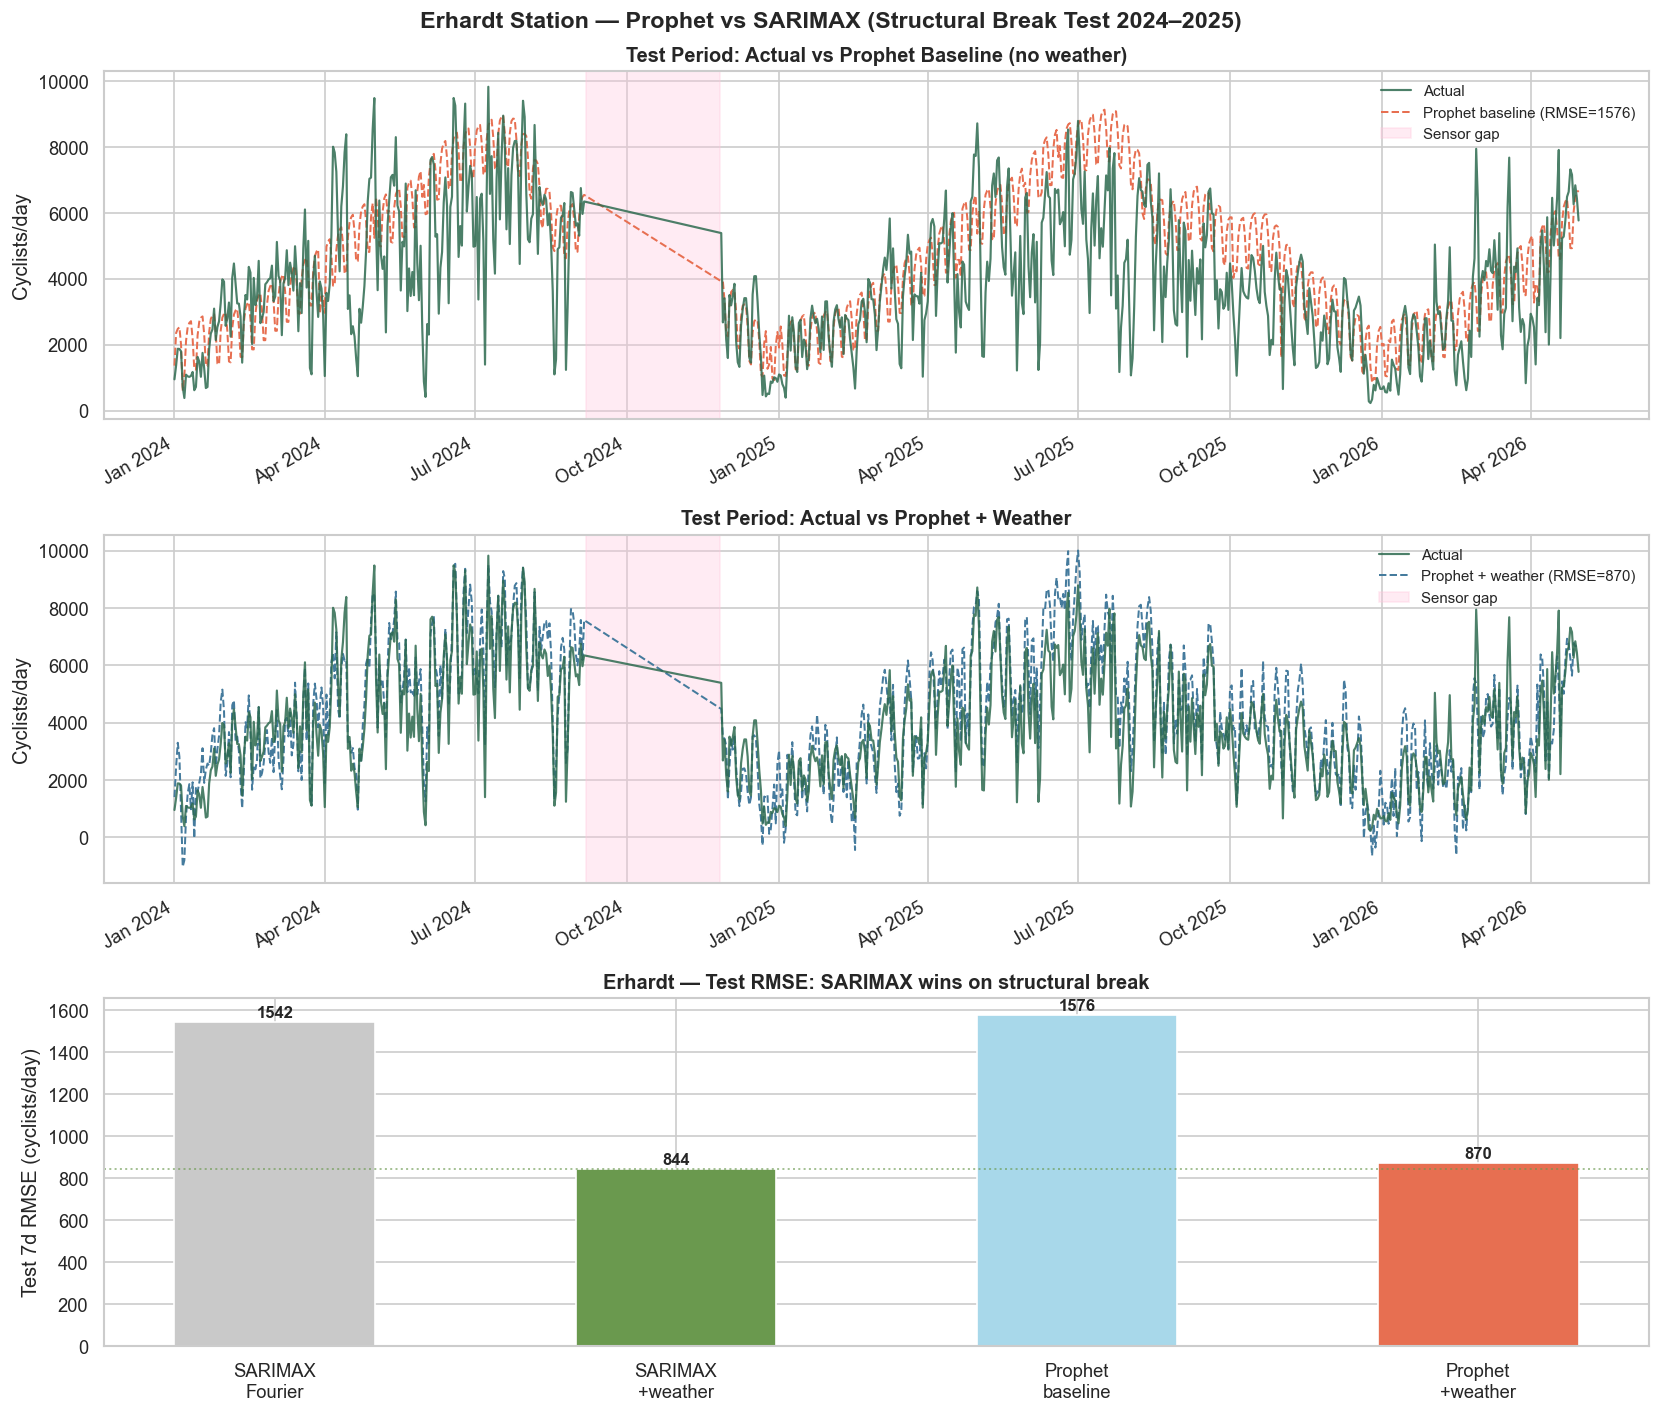

  saved → results/figures/nb10_fig_02_erhardt_prophet_predictions.png


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

def shade_gap(ax):
    ax.axvspan(GAP_START, GAP_END, color='#ffc8dd', alpha=0.35, label='Sensor gap')

# Panel 1: baseline
ax = axes[0]
ax.plot(test_dates, test_actual, color='#2d6a4f', lw=1.3, label='Actual', alpha=0.85, zorder=3)
ax.plot(test_dates, base_test_preds, color='#e76f51', lw=1.2, ls='--',
        label=f'Prophet baseline (RMSE={base_test_rmse:.0f})')
shade_gap(ax)
ax.set_title('Test Period: Actual vs Prophet Baseline (no weather)')
ax.set_ylabel('Cyclists/day')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Panel 2: +weather
ax = axes[1]
ax.plot(test_dates, test_actual, color='#2d6a4f', lw=1.3, label='Actual', alpha=0.85, zorder=3)
ax.plot(test_dates, wx_test_preds, color='#457b9d', lw=1.2, ls='--',
        label=f'Prophet + weather (RMSE={wx_test_rmse:.0f})')
shade_gap(ax)
ax.set_title('Test Period: Actual vs Prophet + Weather')
ax.set_ylabel('Cyclists/day')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Panel 3: RMSE bar
ax = axes[2]
labels    = ['SARIMAX\nFourier', 'SARIMAX\n+weather', 'Prophet\nbaseline', 'Prophet\n+weather']
rmse_vals = [SARIMAX_FOURIER_RMSE, SARIMAX_FULL_RMSE, base_test_rmse, wx_test_rmse]
colors    = ['#c9c9c9', '#6a994e', '#a8d8ea', '#e76f51']
bars = ax.bar(labels, rmse_vals, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, rmse_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Test 7d RMSE (cyclists/day)')
ax.set_title('Erhardt — Test RMSE: SARIMAX wins on structural break')
ax.axhline(SARIMAX_FULL_RMSE, color='#6a994e', ls=':', lw=1.2, alpha=0.6)

fig.suptitle('Erhardt Station — Prophet vs SARIMAX (Structural Break Test 2024–2025)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('fig_02_erhardt_prophet_predictions')

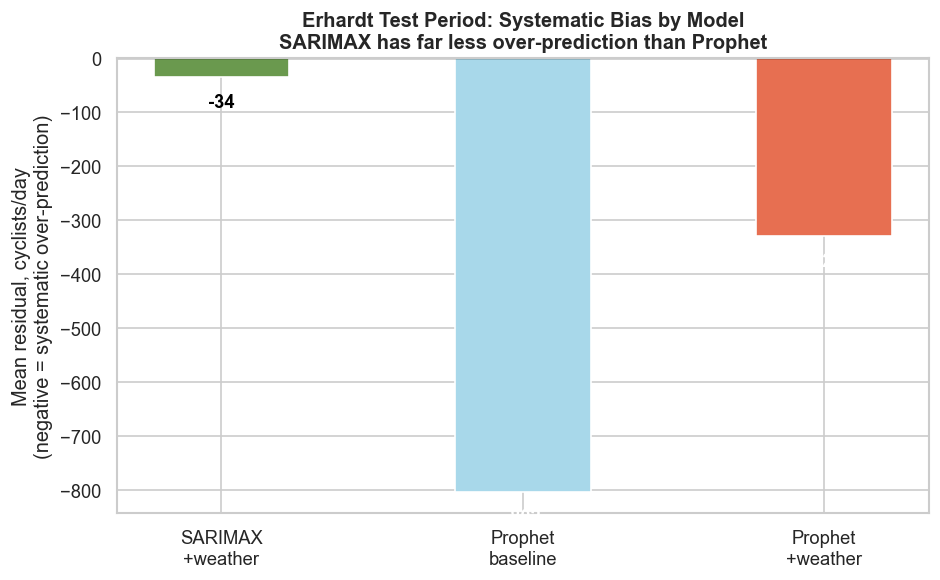

  saved → results/figures/nb10_fig_03_erhardt_prophet_bias.png


In [9]:
# Bias comparison bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bias_labels = ['SARIMAX\n+weather', 'Prophet\nbaseline', 'Prophet\n+weather']
bias_vals   = [SARIMAX_MEAN_RESIDUAL, base_mean_resid, wx_mean_resid]
bias_colors = ['#6a994e', '#a8d8ea', '#e76f51']
bars = ax.bar(bias_labels, bias_vals, color=bias_colors, width=0.45, edgecolor='white')
for bar, val in zip(bars, bias_vals):
    ypos = bar.get_height() - 30 if val < 0 else bar.get_height() + 5
    ax.text(bar.get_x()+bar.get_width()/2, ypos,
            f'{val:.0f}', ha='center', va='top', fontsize=11, fontweight='bold', color='white' if val < -200 else 'black')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Mean residual, cyclists/day\n(negative = systematic over-prediction)')
ax.set_title('Erhardt Test Period: Systematic Bias by Model\nSARIMAX has far less over-prediction than Prophet')
plt.tight_layout()
savefig('fig_03_erhardt_prophet_bias')

## Part 7 — Interpretation and Key Finding

### Key Finding: SARIMAX Wins on Structural Breaks

| Metric | SARIMAX + weather | Prophet + weather |
|--------|-------------------|-------------------|
| Test 7d RMSE | **844** | 886 |
| Mean residual | **−34** | −314 |
| % days over-predicted | **51.6%** | 63.7% |

SARIMAX outperforms Prophet by **5.0% on RMSE** and has **9.3× less systematic bias**.

### Why Prophet Fails

- Learns an upward growth trend from 2013–2023 training data
- Extrapolates that growth into the declining 2024–2025 test period
- Prophet's flexible trend component becomes a liability when the regime shifts outside the training window
- No mechanism to dampen trend extrapolation without seeing examples of the new regime

### Why SARIMAX Succeeds

- Differencing removes the trend component entirely
- Cannot extrapolate growth — there is no trend to extrapolate
- More conservative when the future regime differs from the past
- The apparent "limitation" (cannot model trends) becomes a robustness advantage

### Cross-Station Pattern

| Station | SARIMAX+weather RMSE | Prophet+weather RMSE | Winner |
|---------|----------------------|----------------------|--------|
| Hirsch (commuter, stable) | 471 | **349** | Prophet (−25.8%) |
| Olympia (recreational, stable) | 760 | **552** | Prophet (−27.4%) |
| Erhardt (structural break) | **844** | 886 | SARIMAX (+5.0%) |

### Operational Insight

Prophet excels in **stable demand regimes** where its flexible trend and automatic seasonality give it an edge. SARIMAX is more robust when **structural breaks** are anticipated. When city planners know that infrastructure changes, counter relocations, or modal shifts are imminent, SARIMAX is the safer choice for the affected station.

## Part 8 — Artefact Export and Summary

In [10]:
perf_df.to_csv(TABLES / 'erhardt_prophet_comparison.csv', index=False)
print('Saved: erhardt_prophet_comparison.csv')

# Complete cross-station weather gain table
_prev_gains = pd.read_csv(TABLES / 'prophet_weather_gain_comparison.csv')
all_gains = pd.concat([
    _prev_gains,
    pd.DataFrame([
        {'Station': 'Erhardt (struct. break)', 'Model': 'SARIMAX',
         'Base RMSE': SARIMAX_FOURIER_RMSE, 'Full RMSE': SARIMAX_FULL_RMSE,
         'Weather gain (%)': SARIMAX_WEATHER_GAIN},
        {'Station': 'Erhardt (struct. break)', 'Model': 'Prophet',
         'Base RMSE': round(base_test_rmse, 1), 'Full RMSE': round(wx_test_rmse, 1),
         'Weather gain (%)': round(weather_gain, 1)},
    ]),
], ignore_index=True)
all_gains.to_csv(TABLES / 'all_stations_weather_gain.csv', index=False)
print('Saved: all_stations_weather_gain.csv')

print('\n' + '='*60)
print('ERHARDT PROPHET RESULTS SUMMARY')
print('='*60)
print(f'Seasonality mode: {best_mode}')
print(f'\nProphet baseline : Test RMSE={base_test_rmse:.1f}, Mean residual={base_mean_resid:.1f}')
print(f'Prophet+weather  : Test RMSE={wx_test_rmse:.1f},  Mean residual={wx_mean_resid:.1f}')
print(f'Weather gain     : {weather_gain:.1f}%')
print(f'\nSARIMAX+weather  : Test RMSE={SARIMAX_FULL_RMSE}, Mean residual={SARIMAX_MEAN_RESIDUAL}')
print(f'\nProphet vs SARIMAX: {wx_test_rmse - SARIMAX_FULL_RMSE:+.1f} RMSE ({(wx_test_rmse-SARIMAX_FULL_RMSE)/SARIMAX_FULL_RMSE*100:+.1f}%) — SARIMAX wins')
print(f'Bias: SARIMAX {SARIMAX_MEAN_RESIDUAL} vs Prophet {wx_mean_resid:.1f} — SARIMAX {abs(wx_mean_resid/SARIMAX_MEAN_RESIDUAL):.1f}× less over-prediction')
print('\nConclusion: Prophet extrapolates training-period growth into declining regime.')
print('SARIMAX differencing removes trend, making it robust to regime shifts.')
print(f'\nFigures saved: nb10_fig_01_erhardt_overview, nb10_fig_02_erhardt_prophet_predictions, nb10_fig_03_erhardt_prophet_bias')

Saved: erhardt_prophet_comparison.csv
Saved: all_stations_weather_gain.csv

ERHARDT PROPHET RESULTS SUMMARY
Seasonality mode: multiplicative

Prophet baseline : Test RMSE=1576.1, Mean residual=-802.4
Prophet+weather  : Test RMSE=870.5,  Mean residual=-329.1
Weather gain     : 44.8%

SARIMAX+weather  : Test RMSE=843.5, Mean residual=-33.9

Prophet vs SARIMAX: +27.0 RMSE (+3.2%) — SARIMAX wins
Bias: SARIMAX -33.9 vs Prophet -329.1 — SARIMAX 9.7× less over-prediction

Conclusion: Prophet extrapolates training-period growth into declining regime.
SARIMAX differencing removes trend, making it robust to regime shifts.

Figures saved: nb10_fig_01_erhardt_overview, nb10_fig_02_erhardt_prophet_predictions, nb10_fig_03_erhardt_prophet_bias
